# Feature Exploration with Histograms and Signal Processing
This notebook builds quick visual diagnostics for cervical cytology images.
We will: 
- Load a few images per class
- Show raw histograms
- Apply signal-processing style transforms (contrast stretch, histogram equalization, gamma, edge maps, FFT high-pass)
- Compare before/after side by side

In [16]:
import os
from glob import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [17]:
from pathlib import Path
DATA_ROOT = str(Path("../data").resolve())
CLASSES = ["dyskeratotic", "koilocytotic", "metaplastic", "parabasal", "superficial-intermediate"]
SEED = 7
SAMPLES_PER_CLASS = 2

random.seed(SEED)

def list_images_for_class(class_name):
    folder_name = "im_Superficial-Intermediate" if class_name == "superficial-intermediate" else f"im_{class_name.capitalize()}"
    pattern = os.path.join(DATA_ROOT, "sipakmed", folder_name, "CROPPED", "*.bmp")
    files = glob(pattern)
    if not files:
        # Some datasets might use jpg or png
        pattern = os.path.join(DATA_ROOT, "sipakmed", folder_name, "CROPPED", "*.*")
        files = [f for f in glob(pattern) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    return sorted(files)

def sample_images_per_class():
    samples = {}
    for cls in CLASSES:
        files = list_images_for_class(cls)
        if not files:
            samples[cls] = []
            continue
        if len(files) <= SAMPLES_PER_CLASS:
            samples[cls] = files
        else:
            samples[cls] = random.sample(files, SAMPLES_PER_CLASS)
    return samples

samples = sample_images_per_class()
{k: len(v) for k, v in samples.items()}

{'dyskeratotic': 2,
 'koilocytotic': 2,
 'metaplastic': 2,
 'parabasal': 2,
 'superficial-intermediate': 2}

In [18]:
# Dataset overview and file counts
if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")

counts = {cls: len(list_images_for_class(cls)) for cls in CLASSES}
count_df = pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
count_df.loc["total"] = count_df["count"].sum()
count_df

,count
dyskeratotic,813
koilocytotic,825
metaplastic,793
parabasal,787
superficial-intermediate,831
total,4049


In [19]:
def load_image(path):
    img = Image.open(path).convert("RGB")
    return np.array(img)

def to_gray(img):
    # Luma transform
    return (0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]).astype(np.float32)

def contrast_stretch(gray):
    p2, p98 = np.percentile(gray, (2, 98))
    if p98 - p2 < 1e-6:
        return gray.copy()
    out = (gray - p2) / (p98 - p2)
    return np.clip(out, 0, 1)

def hist_equalize(gray):
    # Histogram equalization on [0, 1]
    g = np.clip(gray, 0, 1)
    hist, bins = np.histogram(g.flatten(), bins=256, range=(0, 1), density=False)
    cdf = hist.cumsum()
    cdf = cdf / cdf[-1]
    out = np.interp(g.flatten(), bins[:-1], cdf).reshape(g.shape)
    return out

def gamma_correction(gray, gamma=0.8):
    g = np.clip(gray, 0, 1)
    return np.power(g, gamma)

def conv2d(gray, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(gray, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    out = np.zeros_like(gray, dtype=np.float32)
    for i in range(gray.shape[0]):
        for j in range(gray.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)
    return out

def sobel_edges(gray):
    kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    gx = conv2d(gray, kx)
    gy = conv2d(gray, ky)
    mag = np.sqrt(gx**2 + gy**2)
    mag = mag / (mag.max() + 1e-6)
    return mag

def local_variance(gray, k=7):
    kernel = np.ones((k, k), dtype=np.float32) / float(k * k)
    mean = conv2d(gray, kernel)
    mean2 = conv2d(gray**2, kernel)
    var = mean2 - mean**2
    var = var - var.min()
    return var / (var.max() + 1e-6)

def fft_highpass(gray, radius=20):
    g = gray - gray.mean()
    f = np.fft.fft2(g)
    fshift = np.fft.fftshift(f)
    rows, cols = gray.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), dtype=np.float32)
    y, x = np.ogrid[:rows, :cols]
    dist = (y - crow)**2 + (x - ccol)**2
    mask[dist <= radius**2] = 0.0
    fshift = fshift * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    out = np.abs(img_back)
    out = out / (out.max() + 1e-6)
    return out

def entropy_from_gray(gray, bins=256):
    hist, _ = np.histogram(gray.flatten(), bins=bins, range=(0, 1), density=True)
    hist = hist[hist > 0]
    return float(-np.sum(hist * np.log2(hist)))

def skewness(gray):
    m = float(np.mean(gray))
    s = float(np.std(gray))
    if s < 1e-6:
        return 0.0
    return float(np.mean(((gray - m) / s) ** 3))

def extract_features(gray, edges, hp, varmap):
    return {
        "mean": float(np.mean(gray)),
        "std": float(np.std(gray)),
        "skew": skewness(gray),
        "entropy": entropy_from_gray(gray),
        "edge_density": float(np.mean(edges)),
        "high_freq_energy": float(np.mean(hp)),
        "local_var": float(np.mean(varmap)),
    }

def show_image_grid(images, titles, ncols=3, figsize=(10, 8), cmap=None):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)
    for idx, ax in enumerate(axes.ravel()):
        if idx < n:
            ax.imshow(images[idx], cmap=cmap)
            ax.set_title(titles[idx], fontsize=9)
            ax.axis("off")
        else:
            ax.axis("off")
    plt.tight_layout()

def plot_histogram(gray, title):
    plt.hist(gray.flatten(), bins=256, range=(0, 1), color="#34495e")
    plt.title(title, fontsize=9)
    plt.xlabel("Intensity")
    plt.ylabel("Count")

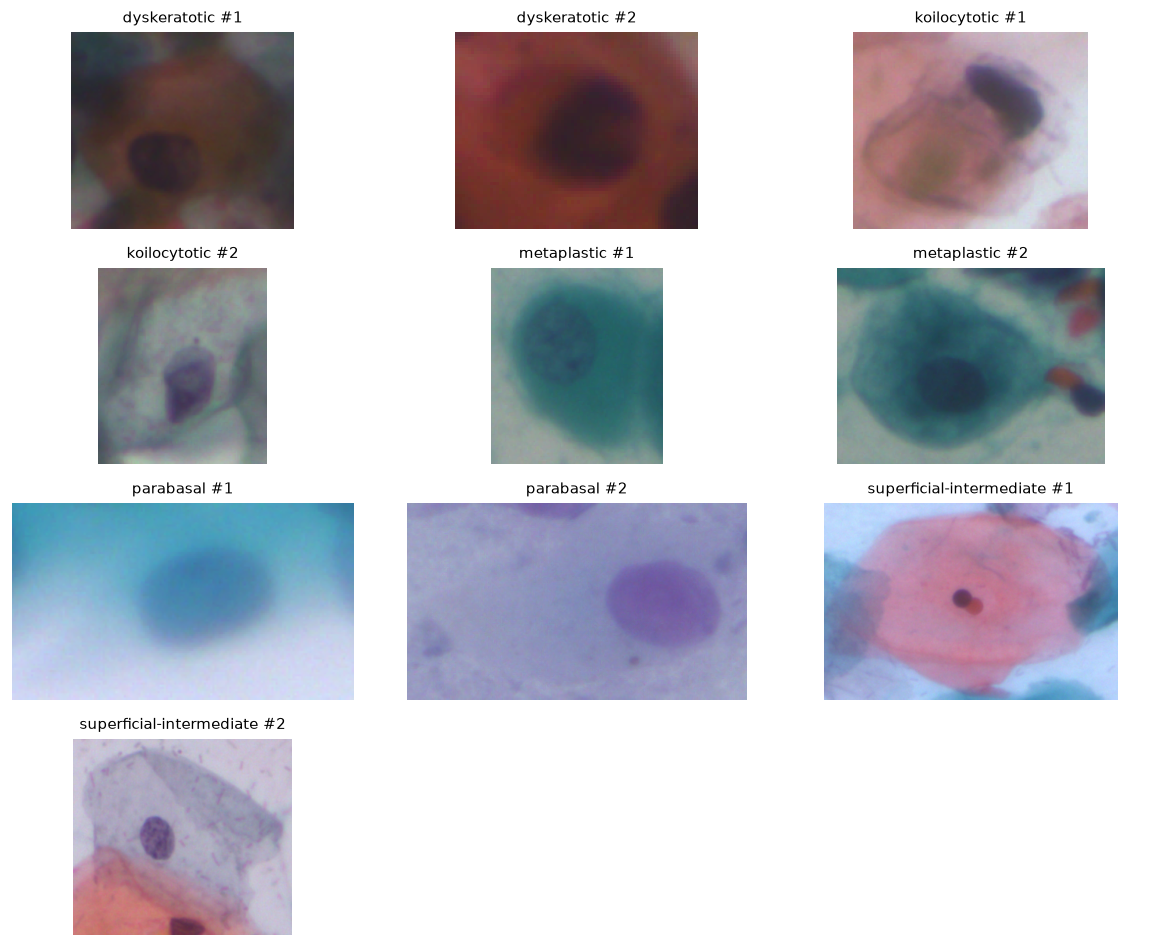

In [20]:
# Show a quick gallery of raw images
raw_images = []
raw_titles = []

for cls, files in samples.items():
    for i, fpath in enumerate(files):
        img = load_image(fpath)
        raw_images.append(img)
        raw_titles.append(f"{cls} #{i+1}")

if raw_images:
    show_image_grid(raw_images, raw_titles, ncols=3, figsize=(10, 8))
else:
    print("No images found. Check DATA_ROOT and folder structure.")

Class: dyskeratotic


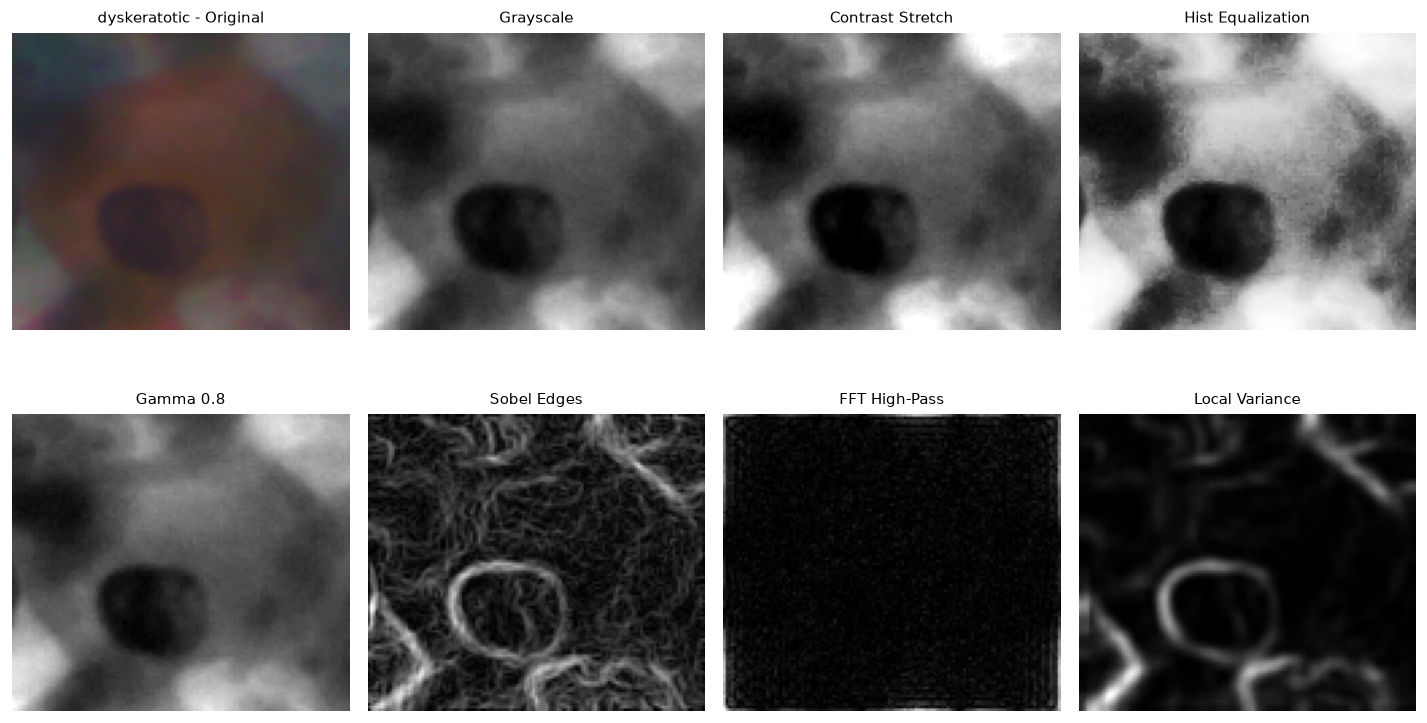

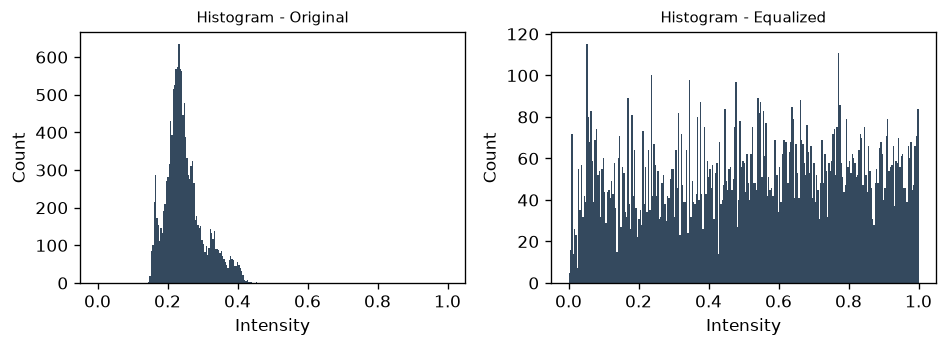

Class: koilocytotic


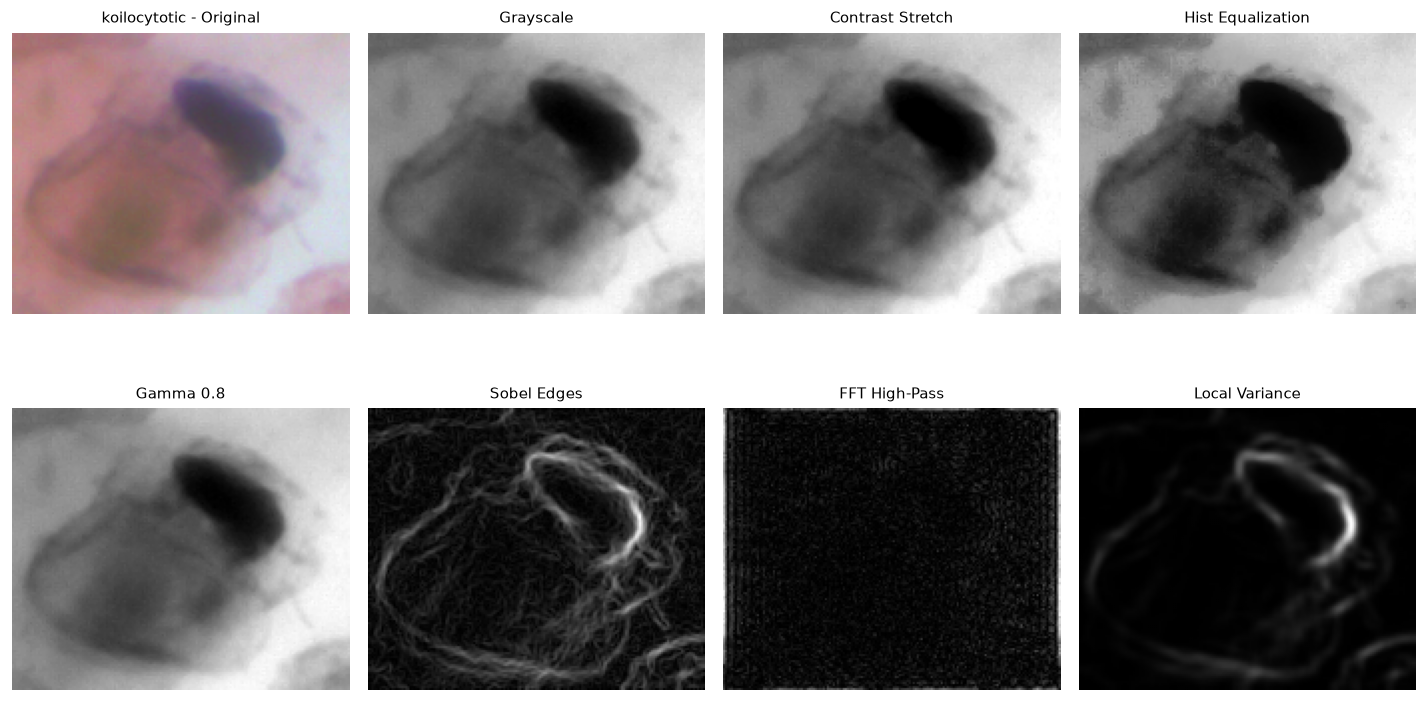

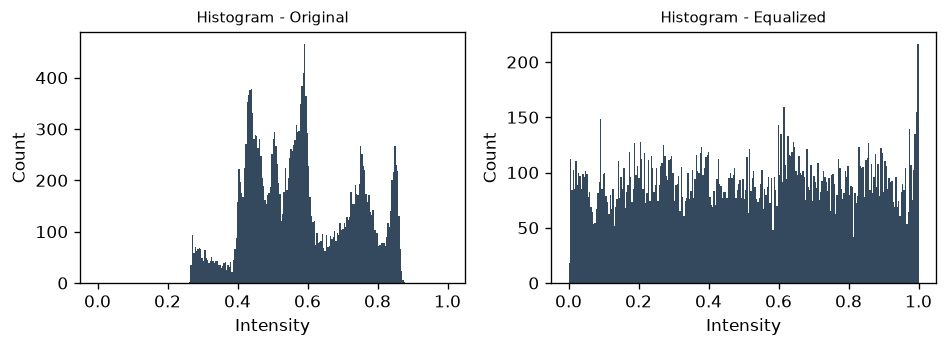

Class: metaplastic


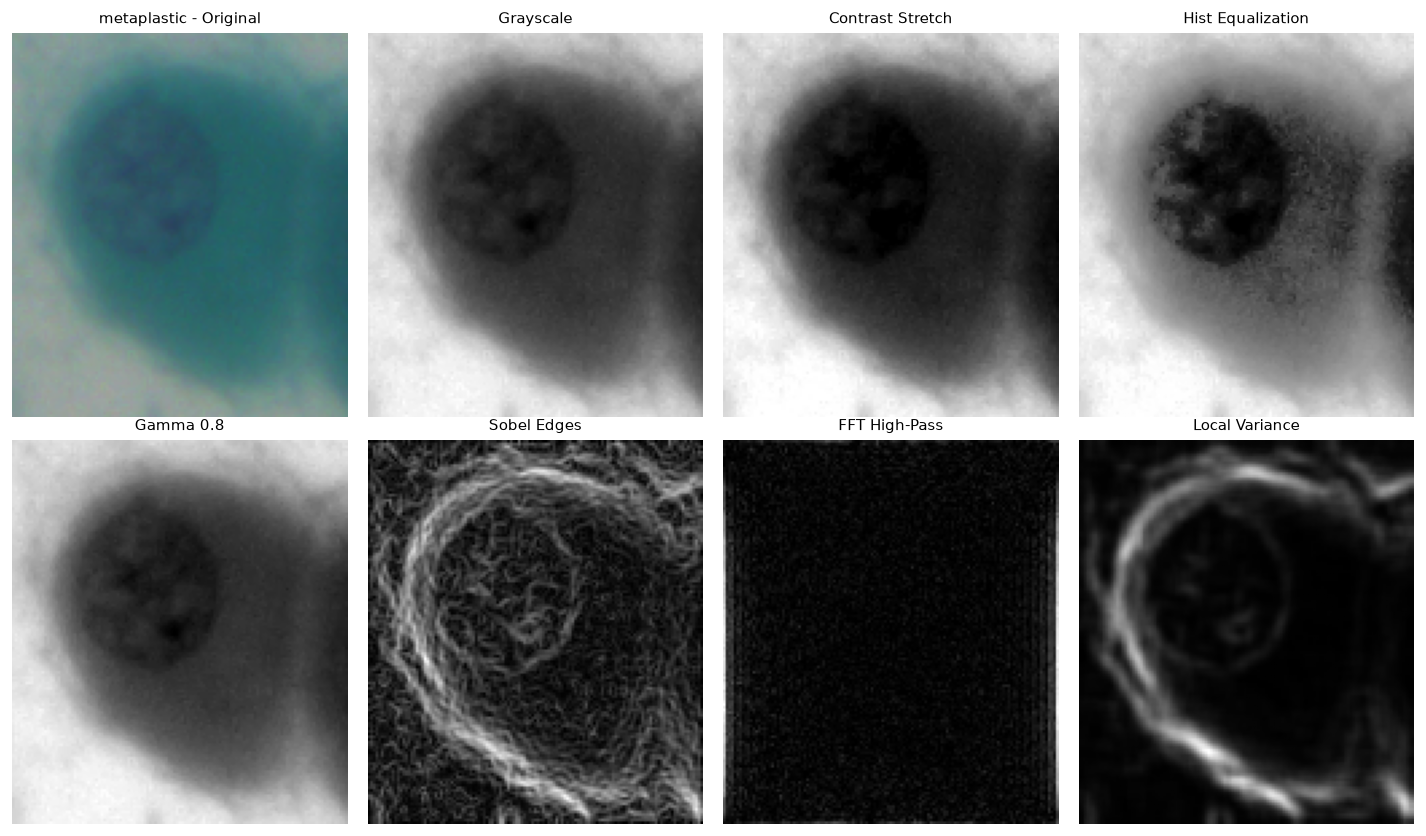

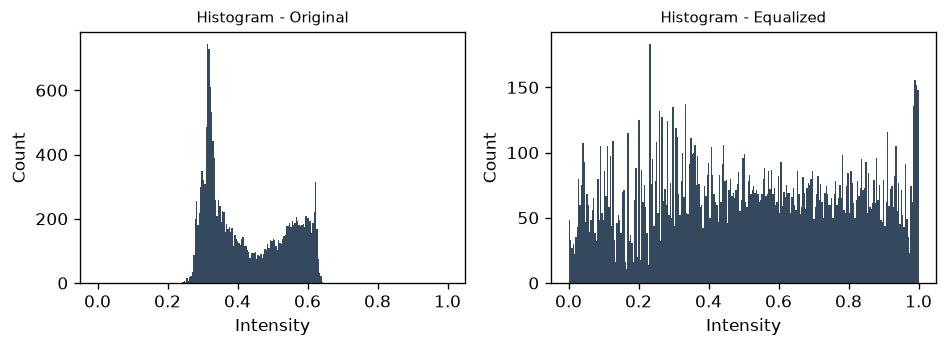

Class: parabasal


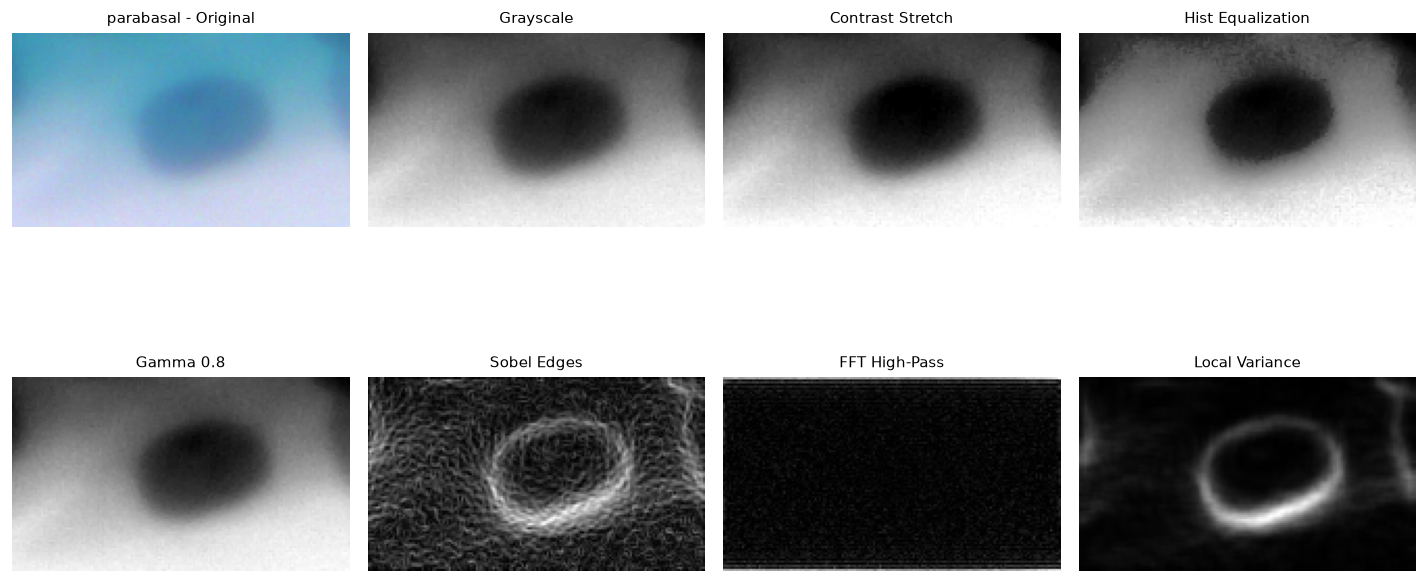

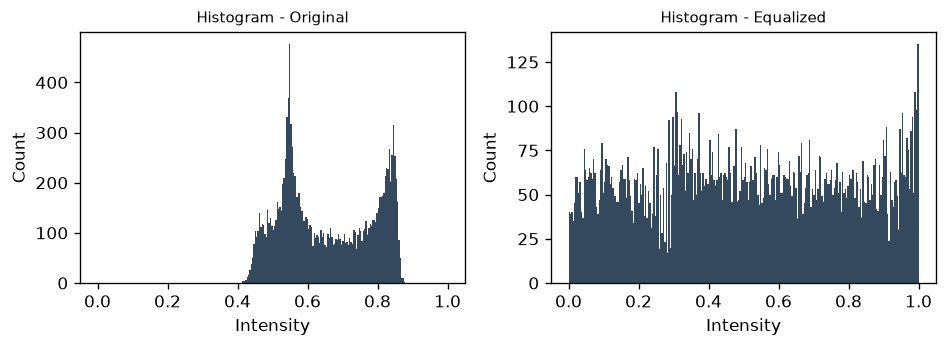

Class: superficial-intermediate


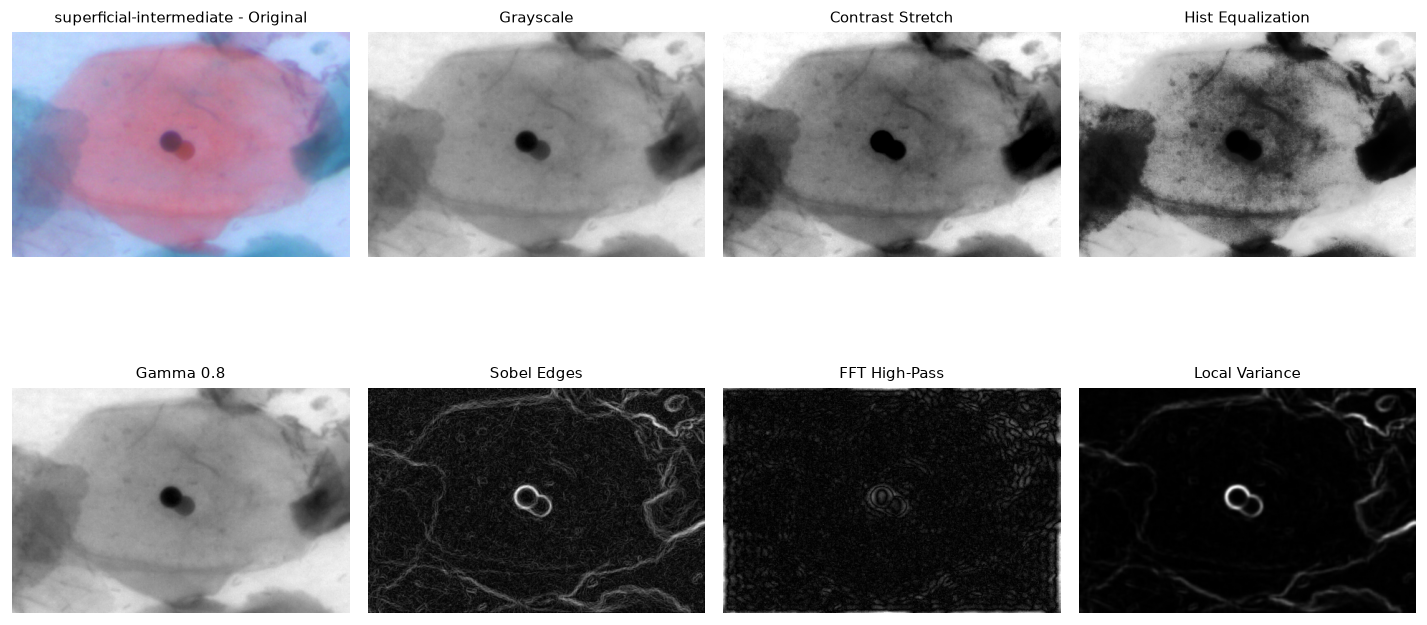

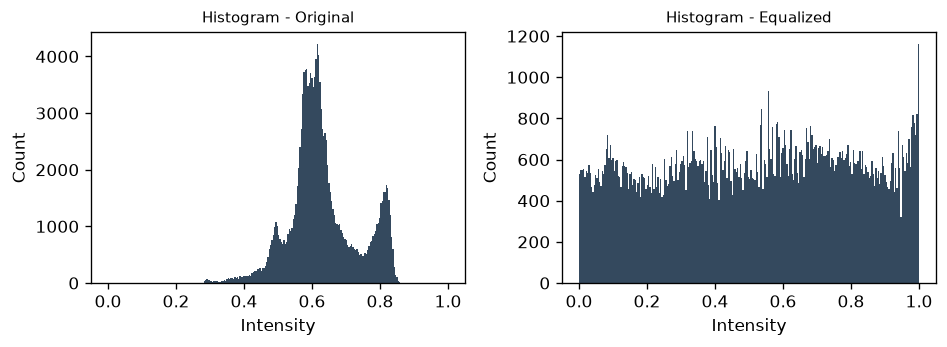

In [21]:
# Before/after preprocessing for one sample per class
for cls, files in samples.items():
    if not files:
        continue
    path = files[0]
    img = load_image(path)
    gray = to_gray(img) / 255.0

    stretched = contrast_stretch(gray)
    equalized = hist_equalize(gray)
    gamma = gamma_correction(gray, gamma=0.8)
    edges = sobel_edges(gray)
    hp = fft_highpass(gray, radius=20)
    varmap = local_variance(gray, k=7)

    images = [img, gray, stretched, equalized, gamma, edges, hp, varmap]
    titles = [
        f"{cls} - Original",
        "Grayscale",
        "Contrast Stretch",
        "Hist Equalization",
        "Gamma 0.8",
        "Sobel Edges",
        "FFT High-Pass",
        "Local Variance"
    ]

    print(f"Class: {cls}")
    show_image_grid(images, titles, ncols=4, figsize=(12, 7), cmap="gray")

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plot_histogram(gray, "Histogram - Original")
    plt.subplot(1, 2, 2)
    plot_histogram(equalized, "Histogram - Equalized")
    plt.tight_layout()
    plt.show()

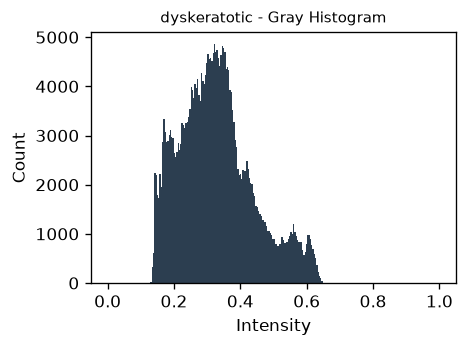

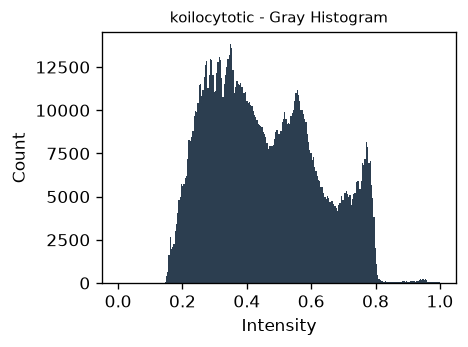

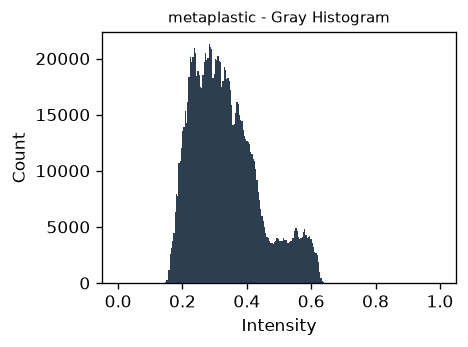

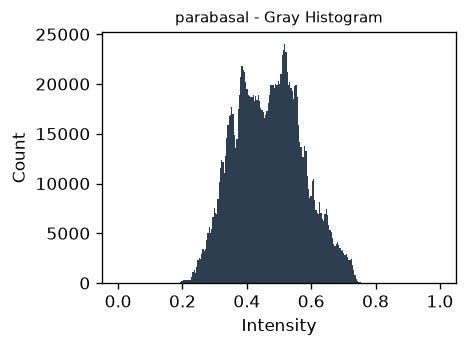

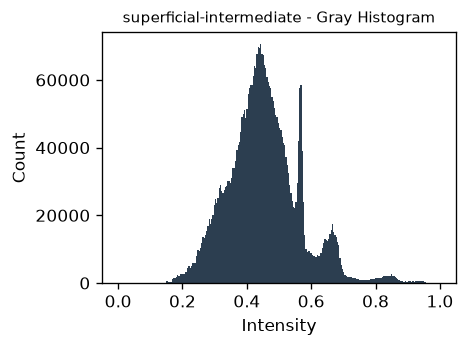

In [22]:
# Aggregate histogram per class from a small random subset
MAX_PER_CLASS = 30

for cls in CLASSES:
    files = list_images_for_class(cls)
    if not files:
        continue
    files = files[:MAX_PER_CLASS]
    pixels = []
    for fpath in files:
        img = load_image(fpath)
        gray = to_gray(img) / 255.0
        pixels.append(gray.flatten())
    pixels = np.concatenate(pixels)

    plt.figure(figsize=(4, 3))
    plt.hist(pixels, bins=256, range=(0, 1), color="#2c3e50")
    plt.title(f"{cls} - Gray Histogram", fontsize=9)
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

,mean,std,skew,entropy,edge_density,high_freq_energy,local_var,class
0,0.308178,0.102835,0.196358,-386.170019,0.177828,0.048997,0.098789,dyskeratotic
1,0.577998,0.094976,0.644137,-466.336904,0.163329,0.057266,0.069982,dyskeratotic
2,0.421176,0.074937,0.074601,-458.869146,0.156968,0.058383,0.069645,dyskeratotic
3,0.336848,0.063420,-0.910190,-557.547625,0.146159,0.065860,0.060210,dyskeratotic
4,0.272578,0.063783,0.440286,-519.077251,0.201625,0.054569,0.118998,dyskeratotic


mean             std            skew          \
                            mean     std    mean     std    mean     std   
class                                                                      
dyskeratotic              0.4255  0.1021  0.1120  0.0423  0.0364  0.5569   
koilocytotic              0.5716  0.1090  0.1625  0.0322  0.0624  0.5359   
metaplastic               0.4654  0.1234  0.1340  0.0425  0.5993  0.4604   
parabasal                 0.5429  0.1150  0.0804  0.0228 -0.3552  0.4743   
superficial-intermediate  0.6108  0.1295  0.1060  0.0272 -0.2770  0.5599   

                           entropy           edge_density          \
                              mean       std         mean     std   
class                                                               
dyskeratotic             -391.0647  120.1300       0.1707  0.0335   
koilocytotic             -264.1071   83.8419       0.1511  0.0293   
metaplastic              -353.6349   98.6180       0.1402  0.0364   
parabasal                -475.8134  107.3381       0.1926  0.0354   
superficial-intermediate -405.0442   90.4558       0.1094  0.0227   

                         high_freq_energy         local_var          
                                     mean     std      mean     std  
class                                                                
dyskeratotic                       0.0551  0.0150    0.0838  0.0268  
koilocytotic                       0.0506  0.0174    0.0662  0.0222  
metaplastic                        0.0510  0.0149    0.0567  0.0215  
parabasal                          0.0505  0.0132    0.0809  0.0266  
superficial-intermediate           0.0506  0.0141    0.0298  0.0102

<Figure size 600x360 with 0 Axes>

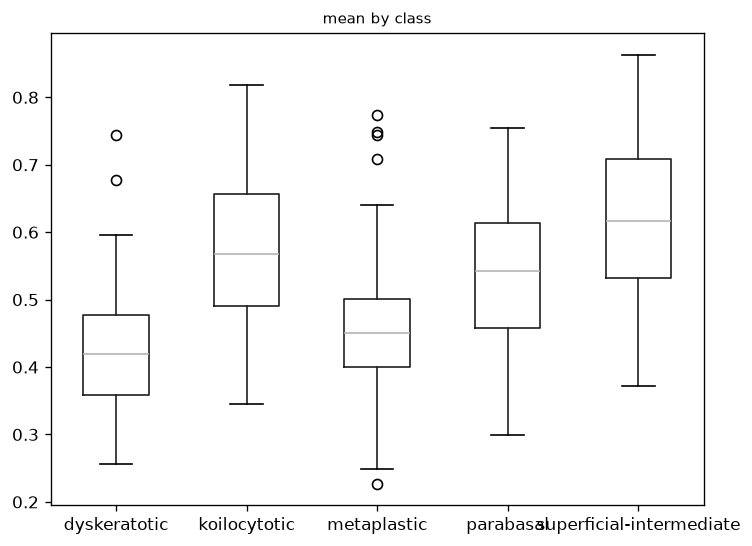

<Figure size 600x360 with 0 Axes>

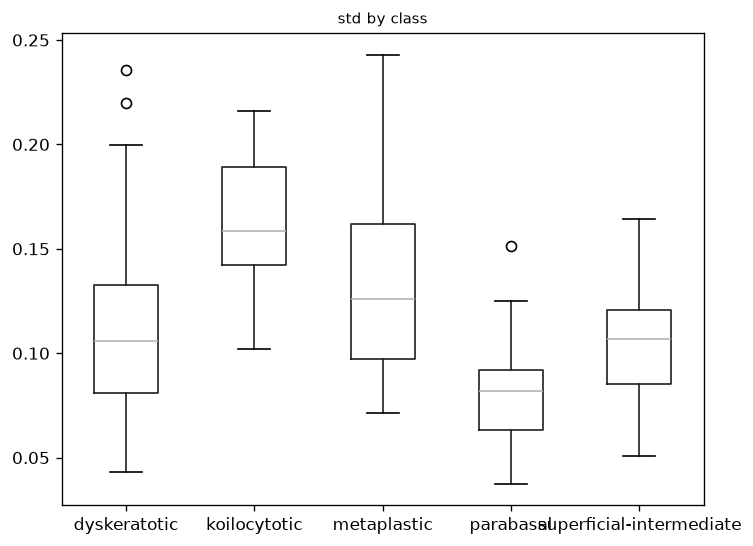

<Figure size 600x360 with 0 Axes>

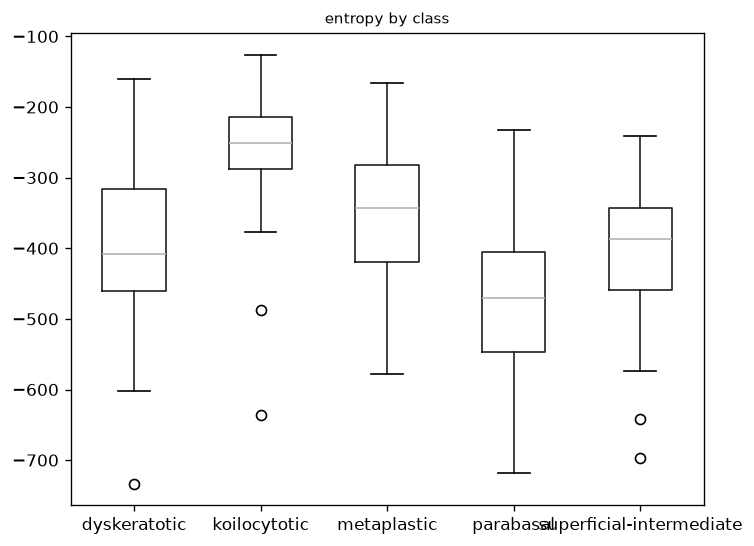

<Figure size 600x360 with 0 Axes>

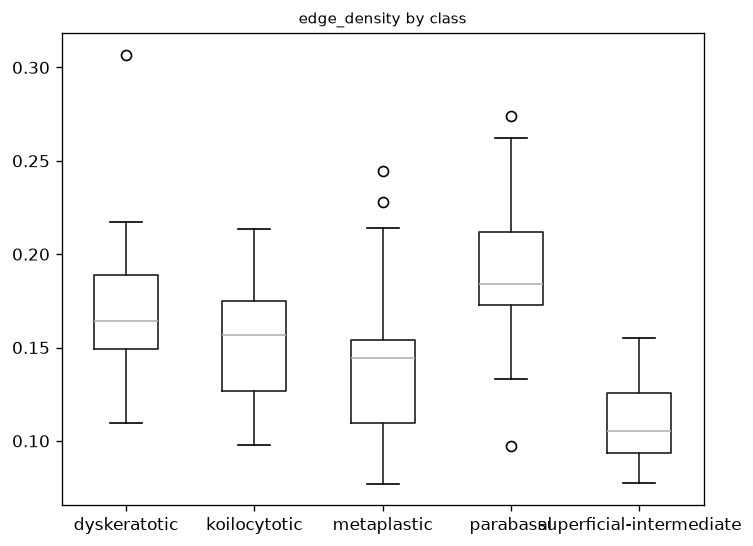

<Figure size 600x360 with 0 Axes>

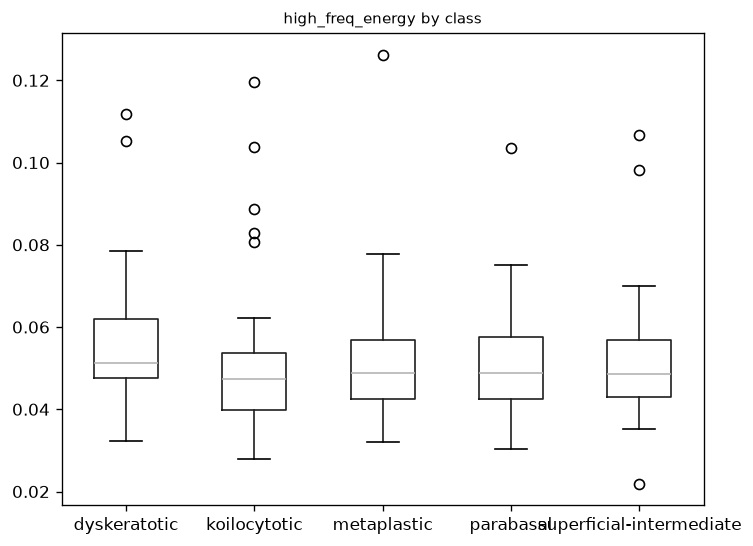

<Figure size 600x360 with 0 Axes>

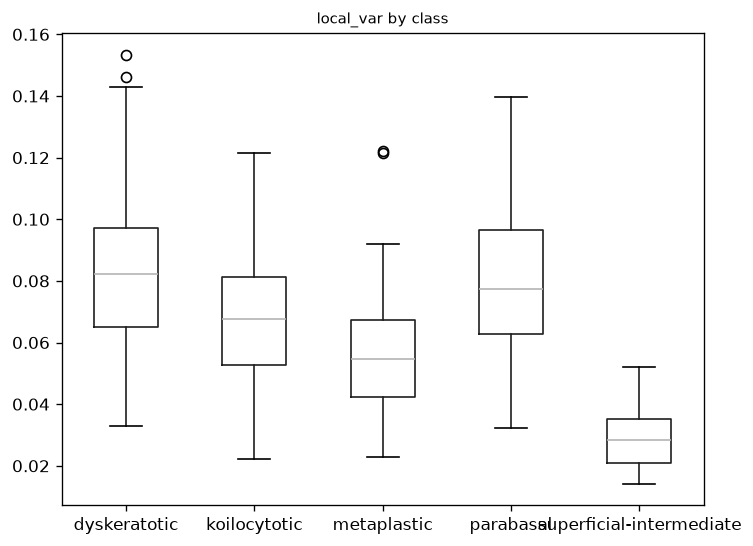

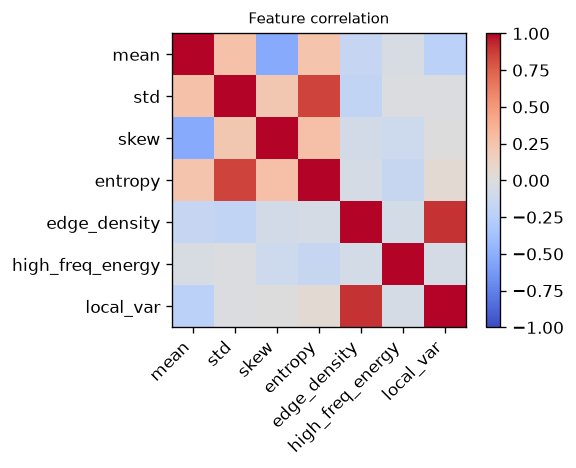

In [23]:
# Feature extraction across a subset of images per class
MAX_FEATURE_SAMPLES = 50

rows = []
for cls in CLASSES:
    files = list_images_for_class(cls)
    if not files:
        continue
    files = random.sample(files, min(len(files), MAX_FEATURE_SAMPLES))
    for fpath in files:
        img = load_image(fpath)
        gray = to_gray(img) / 255.0
        edges = sobel_edges(gray)
        hp = fft_highpass(gray, radius=20)
        varmap = local_variance(gray, k=7)

        feats = extract_features(gray, edges, hp, varmap)
        feats["class"] = cls
        rows.append(feats)

if not rows:
    print("No features extracted. Check file paths and extensions.")
else:
    df = pd.DataFrame(rows)
    display(df.head())

    # Summary statistics per class
    stats = df.groupby("class").agg(["mean", "std"]).round(4)
    display(stats)

    # Boxplots for feature distributions per class
    features_to_plot = ["mean", "std", "entropy", "edge_density", "high_freq_energy", "local_var"]
    for feat in features_to_plot:
        plt.figure(figsize=(5, 3))
        df.boxplot(column=feat, by="class", grid=False)
        plt.title(f"{feat} by class", fontsize=9)
        plt.suptitle("")
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

    # Correlation among features
    plt.figure(figsize=(5, 4))
    corr = df.drop(columns=["class"]).corr()
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Feature correlation", fontsize=9)
    plt.tight_layout()
    plt.show()

## Deeper feature analysis
This section extracts simple numerical descriptors from each class and compares their distributions. It helps identify which transforms highlight class differences that can be used as extra features.

## Notes for feature engineering
You can extract numerical features from these transforms and feed them to your network or a classical model, for example:
- Intensity histogram moments (mean, std, skew)
- Edge density (mean of Sobel magnitude)
- High-frequency energy from FFT magnitude
- Texture descriptors computed over contrast-stretched or equalized images

## Image Classification using KL Divergence
Here we build a simple model to classify an image based on the Kullback-Leibler (KL) divergence of its pixel distribution compared to reference images.

In [24]:
from scipy.stats import entropy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

def get_pixel_dist(gray_img, bins=256):
    if gray_img.max() > 1.0:
        gray_img = gray_img / 255.0
    hist, _ = np.histogram(gray_img.flatten(), bins=bins, range=(0, 1), density=True)
    hist = hist + 1e-10
    return hist / np.sum(hist)

def build_references(train_samples):
    references = {}
    for cls, paths in train_samples.items():
        dists = []
        for p in paths:
            img = load_image(p)
            gray = to_gray(img)
            dists.append(get_pixel_dist(gray))
        references[cls] = dists
    return references

def predict_kl(image_path, reference_dists):
    img = load_image(image_path)
    gray = to_gray(img)
    dist = get_pixel_dist(gray)
    
    kl_means = {}
    for cls, ref_dists in reference_dists.items():
        kl_divs = [entropy(dist, ref) for ref in ref_dists]
        kl_means[cls] = np.mean(kl_divs)
        
    best_cls = min(kl_means, key=kl_means.get)
    return best_cls

In [25]:
SAMPLES_PER_CLASS_TOTAL = 40  # using 40 images per class to keep it fast

train_paths = {}
test_paths = {}
y_true = []
test_images = []

for cls in CLASSES:
    files = list_images_for_class(cls)
    subset = random.sample(files, min(SAMPLES_PER_CLASS_TOTAL, len(files)))
    train, test = train_test_split(subset, test_size=0.5, random_state=SEED)
    train_paths[cls] = train
    test_paths[cls] = test
    for t in test:
        test_images.append(t)
        y_true.append(cls)

print("Building reference distributions...")
reference_dists = build_references(train_paths)

print("Evaluating test set...")
y_pred = []
for p in test_images:
    y_pred.append(predict_kl(p, reference_dists))

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Building reference distributions...
Evaluating test set...
Accuracy: 0.3100
Precision: 0.1850
Recall: 0.3100
F1 Score: 0.2145


## Classificador CNN + Divergência KL Gaussiana

**Evolução da ideia anterior:** em vez de comparar histogramas de pixels crus, passamos as imagens
por uma CNN treinável e comparamos as distribuições **no espaço latente**.

**Arquitetura:**
1. **Banco de referência**: 30 imagens por classe (fixas, não-treináveis)
2. **CNN Encoder**: Mapeia imagens → espaço latente $\mathbb{R}^d$ (pesos treináveis)
3. **Distribuições por classe**: $\mathcal{N}(\mu_c, \sigma^2_c)$ com covariância diagonal (normais independentes)
4. **Classificação**: Log-verossimilhança negativa (equiv. a $D_{KL}$) da query sob cada Gaussiana

$$\text{logit}_c = -\frac{1}{2}\sum_{j=1}^{d} \left[\log \sigma_{c,j}^2 + \frac{(z_j - \mu_{c,j})^2}{\sigma_{c,j}^2}\right]$$

Toda a pipeline é **diferenciável** e treinável end-to-end.

In [26]:
# ── Imports adicionais para o modelo CNN ──
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [27]:
# ── Hiperparâmetros do modelo CNN+KL ──
NUM_CLASSES = len(CLASSES)
LATENT_DIM = 32          # dimensão do espaço latente
REF_PER_CLASS = 30       # imagens de referência por classe (banco fixo)
IMG_SIZE = 128           # tamanho das imagens (resize)
CNN_BATCH_SIZE = 32
CNN_EPOCHS = 30
CNN_LR = 1e-3
REF_SUBSAMPLE = 15       # sub-amostra das refs por step (regularização)

In [28]:
# ── Dataset PyTorch e divisão dos dados ──
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CellDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Separar: banco de referência (fixo) + treino + teste
# Reutiliza list_images_for_class() já definido acima
random.seed(SEED)
cnn_ref_paths = []
cnn_train_paths, cnn_train_labels = [], []
cnn_test_paths, cnn_test_labels = [], []

for cls_idx, cls_name in enumerate(CLASSES):
    files = list_images_for_class(cls_name)
    random.shuffle(files)

    ref = files[:REF_PER_CLASS]
    remaining = files[REF_PER_CLASS:]
    n_test = int(len(remaining) * 0.3)

    cnn_ref_paths.append(ref)
    cnn_test_paths.extend(remaining[:n_test])
    cnn_test_labels.extend([cls_idx] * n_test)
    cnn_train_paths.extend(remaining[n_test:])
    cnn_train_labels.extend([cls_idx] * len(remaining[n_test:]))

print('Banco de referência por classe:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls}: {len(cnn_ref_paths[i])}')
print(f'\nTreino: {len(cnn_train_paths)}  |  Teste: {len(cnn_test_paths)}')

train_ds = CellDataset(cnn_train_paths, cnn_train_labels, train_transform)
test_ds  = CellDataset(cnn_test_paths, cnn_test_labels, eval_transform)

cnn_train_loader = DataLoader(train_ds, batch_size=CNN_BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
cnn_test_loader  = DataLoader(test_ds,  batch_size=CNN_BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

Banco de referência por classe:
  dyskeratotic: 30
  koilocytotic: 30
  metaplastic: 30
  parabasal: 30
  superficial-intermediate: 30

Treino: 2732  |  Teste: 1167


In [29]:
# ── Pré-carregar banco de referência na memória ──
def load_reference_bank(ref_paths_per_class, transform):
    """Carrega todas as imagens de referência como tensores."""
    bank = []
    for cls_paths in ref_paths_per_class:
        imgs = []
        for p in cls_paths:
            img = Image.open(p).convert('RGB')
            imgs.append(transform(img))
        bank.append(torch.stack(imgs))
    return bank

ref_bank = load_reference_bank(cnn_ref_paths, eval_transform)

print('Banco de referência carregado:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls}: {ref_bank[i].shape}')

Banco de referência carregado:
  dyskeratotic: torch.Size([30, 3, 128, 128])
  koilocytotic: torch.Size([30, 3, 128, 128])
  metaplastic: torch.Size([30, 3, 128, 128])
  parabasal: torch.Size([30, 3, 128, 128])
  superficial-intermediate: torch.Size([30, 3, 128, 128])


In [30]:
NUM_CLASSES = len(CLASSES)
# ── Modelo: CNN Encoder + Classificador Gaussiano (KL) ──
class GaussianKLClassifier(nn.Module):
    """CNN encoder + classificação por distância Gaussiana diagonal (KL)."""

    def __init__(self, num_classes=5, latent_dim=32, eps=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        self.eps = eps

        self.encoder = nn.Sequential(
            # Bloco 1: 128 → 64
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloco 2: 64 → 32
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloco 3: 32 → 16
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Pooling global + projeção para espaço latente
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, latent_dim),
        )

    def encode(self, x):
        return self.encoder(x)

    def compute_class_stats(self, ref_features_per_class):
        """Calcula μ e σ² por classe (covariância diagonal)."""
        means, variances = [], []
        for feats in ref_features_per_class:
            means.append(feats.mean(dim=0))
            variances.append(feats.var(dim=0, unbiased=True) + self.eps)
        return torch.stack(means), torch.stack(variances)

    def forward(self, x, ref_bank, ref_subsample=None):
        # Encode queries
        z = self.encode(x)

        # Encode referências e calcular estatísticas por classe
        ref_features = []
        for ref_imgs in ref_bank:
            if ref_subsample and ref_imgs.size(0) > ref_subsample:
                idx = torch.randperm(ref_imgs.size(0))[:ref_subsample]
                ref_imgs = ref_imgs[idx]
            ref_features.append(self.encode(ref_imgs.to(x.device)))

        class_means, class_vars = self.compute_class_stats(ref_features)

        # NLL Gaussiana diagonal — equivale à D_KL
        z_exp = z.unsqueeze(1)               # (B, 1, D)
        mu = class_means.unsqueeze(0)         # (1, C, D)
        var = class_vars.unsqueeze(0)         # (1, C, D)

        nll = 0.5 * (torch.log(var) + (z_exp - mu).pow(2) / var).sum(dim=-1)
        logits = -nll  # (B, C)

        return logits, class_means, class_vars

model = GaussianKLClassifier(
    num_classes=NUM_CLASSES,
    latent_dim=LATENT_DIM
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Modelo criado: {total_params:,} parâmetros')
print(model)

Modelo criado: 298,240 parâmetros
GaussianKLClassifier(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

In [31]:
# ── Treinamento ──
optimizer = optim.Adam(model.parameters(), lr=CNN_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CNN_EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, CNN_EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in cnn_train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits, _, _ = model(imgs, ref_bank, ref_subsample=REF_SUBSAMPLE)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ── Eval ──
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in cnn_test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits, _, _ = model(imgs, ref_bank, ref_subsample=None)
            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += imgs.size(0)

    test_loss = running_loss / total
    test_acc = correct / total
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{CNN_EPOCHS}  '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  '
              f'Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}')

print('\nTreinamento concluído!')

Epoch   1/30  Train Loss: 1.5662  Acc: 0.4817  |  Test Loss: 6.5752  Acc: 0.6358
Epoch   5/30  Train Loss: 0.9254  Acc: 0.6651  |  Test Loss: 5.1548  Acc: 0.7044
Epoch  10/30  Train Loss: 0.7714  Acc: 0.7094  |  Test Loss: 4.7086  Acc: 0.7524
Epoch  15/30  Train Loss: 0.6245  Acc: 0.7778  |  Test Loss: 3.6503  Acc: 0.7652
Epoch  20/30  Train Loss: 0.5383  Acc: 0.7958  |  Test Loss: 3.7171  Acc: 0.7909
Epoch  25/30  Train Loss: 0.4270  Acc: 0.8430  |  Test Loss: 3.5044  Acc: 0.7918
Epoch  30/30  Train Loss: 0.4160  Acc: 0.8386  |  Test Loss: 3.5255  Acc: 0.7909

Treinamento concluído!


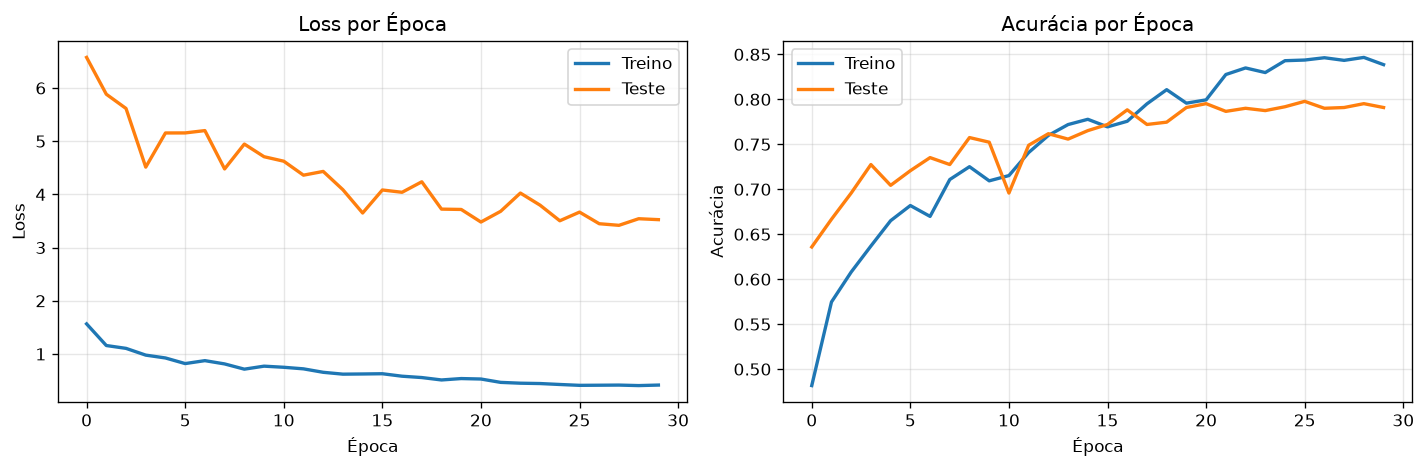

In [32]:
# ── Curvas de treino CNN+KL ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Treino', linewidth=2)
ax1.plot(history['test_loss'], label='Teste', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss por Época')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Treino', linewidth=2)
ax2.plot(history['test_acc'], label='Teste', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_title('Acurácia por Época')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# ── Avaliação final CNN+KL ──
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for imgs, labels in cnn_test_loader:
        imgs = imgs.to(DEVICE)
        logits, _, _ = model(imgs, ref_bank, ref_subsample=None)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

print('=' * 60)
print('RESULTADOS FINAIS — CNN + KL Gaussiana')
print('=' * 60)
print(f'Accuracy:  {accuracy_score(all_true, all_preds):.4f}')
print(f'Precision: {precision_score(all_true, all_preds, average="weighted"):.4f}')
print(f'Recall:    {recall_score(all_true, all_preds, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(all_true, all_preds, average="weighted"):.4f}')


RESULTADOS FINAIS — CNN + KL Gaussiana
Accuracy:  0.7909
Precision: 0.7919
Recall:    0.7909
F1-Score:  0.7906


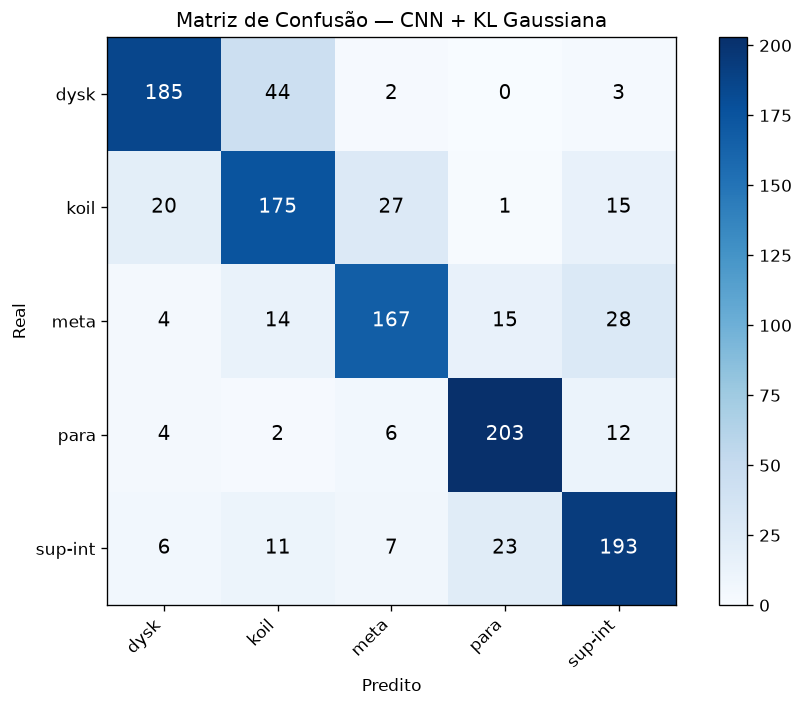

In [34]:
# ── Matriz de Confusão — CNN+KL ──
from sklearn.metrics import confusion_matrix as conf_mat

cm = conf_mat(all_true, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

short_names = ['dysk', 'koil', 'meta', 'para', 'sup-int']
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_yticklabels(short_names)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — CNN + KL Gaussiana')

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=color, fontsize=12)

plt.tight_layout()
plt.show()

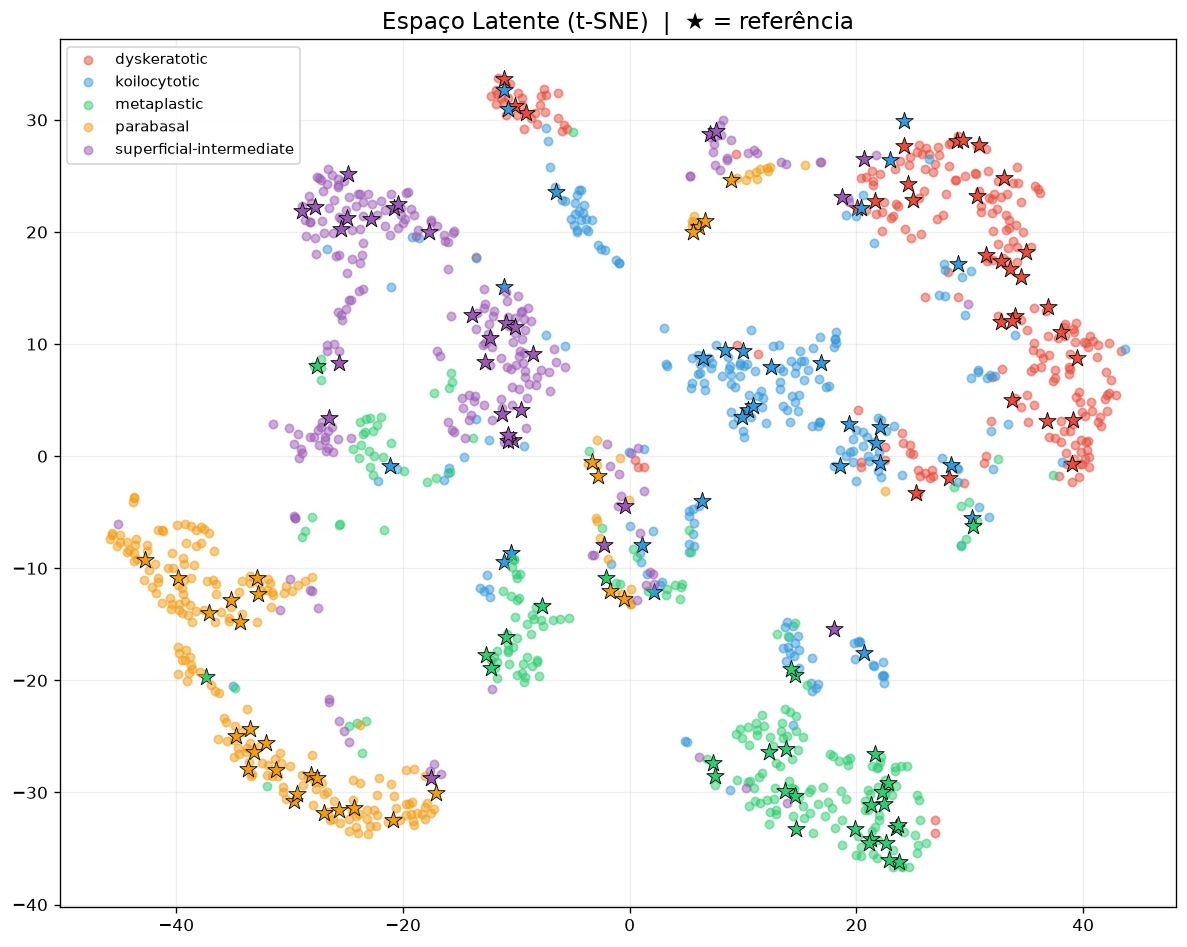

In [35]:
# ── Visualização t-SNE do espaço latente ──
from sklearn.manifold import TSNE

model.eval()
all_features, all_labels_vis, all_types = [], [], []

with torch.no_grad():
    for cls_idx, ref_imgs in enumerate(ref_bank):
        feats = model.encode(ref_imgs.to(DEVICE)).cpu().numpy()
        all_features.append(feats)
        all_labels_vis.extend([cls_idx] * len(feats))
        all_types.extend(['ref'] * len(feats))

    for imgs, labels in cnn_test_loader:
        feats = model.encode(imgs.to(DEVICE)).cpu().numpy()
        all_features.append(feats)
        all_labels_vis.extend(labels.numpy())
        all_types.extend(['test'] * len(feats))

all_features = np.concatenate(all_features)
all_labels_vis = np.array(all_labels_vis)
all_types = np.array(all_types)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
coords = tsne.fit_transform(all_features)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for cls_idx, cls_name in enumerate(CLASSES):
    mask = (all_labels_vis == cls_idx) & (all_types == 'test')
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colors[cls_idx], label=cls_name, alpha=0.5, s=25)
    mask_ref = (all_labels_vis == cls_idx) & (all_types == 'ref')
    ax.scatter(coords[mask_ref, 0], coords[mask_ref, 1],
               c=colors[cls_idx], marker='*', s=120, edgecolors='black',
               linewidths=0.5)

ax.set_title('Espaço Latente (t-SNE)  |  ★ = referência', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [36]:
# ── Estatísticas das distribuições Gaussianas aprendidas ──
model.eval()
with torch.no_grad():
    ref_features = []
    for ref_imgs in ref_bank:
        ref_features.append(model.encode(ref_imgs.to(DEVICE)))
    class_means, class_vars = model.compute_class_stats(ref_features)

print('Estatísticas das distribuições de classe no espaço latente:')
print(f'{"":<30s} {"||μ||":<10s} {"σ² média":<12s} {"σ² min":<12s} {"σ² max":<12s}')
print('─' * 76)
for i, cls in enumerate(CLASSES):
    mu = class_means[i].cpu().numpy()
    var = class_vars[i].cpu().numpy()
    print(f'{cls:<30s} {np.linalg.norm(mu):<10.4f} {var.mean():<12.6f} '
          f'{var.min():<12.6f} {var.max():<12.6f}')

Estatísticas das distribuições de classe no espaço latente:
                               ||μ||      σ² média     σ² min       σ² max      
────────────────────────────────────────────────────────────────────────────
dyskeratotic                   2.3386     0.141985     0.013849     0.440241    
koilocytotic                   1.4325     0.099871     0.016880     0.210215    
metaplastic                    1.4227     0.073154     0.005195     0.324441    
parabasal                      2.2467     0.078114     0.010360     0.261669    
superficial-intermediate       1.6850     0.064055     0.011111     0.184829    
